In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from functions import collect_only, calculate_ic, calculate_r2, calulate_win, calculate_sharpe
import json
import importlib
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, r2_score
from scipy.stats import spearmanr, pearsonr
from regression import run_indicators, tcv_quantile
from trading import simulate_trading, simulate_trading_ensemble, simulate_trading_quantile
from datetime import datetime
from trading import simulate_trading_binary
from regression import run_indicators2
from trading import simulate_trading_poly, simulate_trading_majority

original_columns=['bam_vwa', 'bam_open', 'bam_close',
       'bam_high', 'bam_low', 'bam_volatility_1m_return', 'base_volume',
       'pct_buy_volume', 'annual_interest_rate', 'spread_1m_vwa_vwa',
       'spread_twa']
symbols=['BNB', 'BTC', 'ETH','TRX','XRP']


In [2]:
import warnings
warnings.filterwarnings('ignore')

Testing BNB with trading window 1
Selected indicators: ['volatility_breakout' 'buy_volume_sentiment' 'sma_50' 'sma_200' 'ema_20'
 'ema_50' 'ema_200' 'rsi_14' 'bollinger_bands_20_2' 'obv' 'adx_14'
 'stochastic_oscillator_14' 'ichimoku_cloud_9_26_52' 'vwap' 'atr']
Training on: 2019-04-20 01:00:00 to 2022-04-30 02:00:00
Testing on: 2022-04-30 03:00:00 to 2025-05-08 00:00:00

=== Testing BALANCED LOGISTIC REGRESSION ===
Mean target_return: 0.00016773470410594085
Fraction positive: 0.5117964591748141
Fraction negative: 0.48495715526027705
Using features: ['volatility_breakout', 'buy_volume_sentiment', 'sma_50', 'sma_200', 'ema_20', 'ema_50', 'ema_200', 'rsi_14', 'bollinger_bands_20_2_0', 'bollinger_bands_20_2_1', 'obv', 'adx_14', 'stochastic_oscillator_14_0', 'stochastic_oscillator_14_1', 'ichimoku_cloud_9_26_52_0', 'ichimoku_cloud_9_26_52_1', 'ichimoku_cloud_9_26_52_2', 'ichimoku_cloud_9_26_52_3', 'vwap', 'atr', 'bam_vwa', 'bam_open', 'bam_close', 'bam_high', 'bam_low', 'bam_volatility_1m_

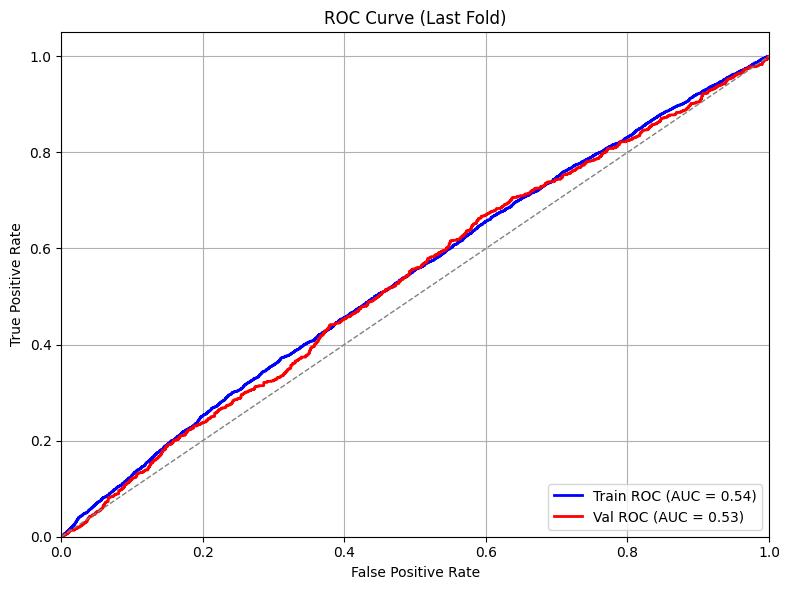

Logistic Regression (Balanced) Walk-Forward Validation Results (9 folds):
Avg Accuracy: 50.88%
Confusion Matrix (Total):
[[6947 4534]
 [7084 5087]]
Classification Report (Last Fold):
              precision    recall  f1-score   support

   Down/Flat       0.51      0.63      0.56      1283
          Up       0.54      0.42      0.47      1345

    accuracy                           0.52      2628
   macro avg       0.53      0.53      0.52      2628
weighted avg       0.53      0.52      0.52      2628

Testing balanced logistic regression on test set...
Test Model Results:
  R² Score: N/A (binary classification model)
  Test samples: 26491
  Features used: 31
  Overall Accuracy: 0.5301 (53.01%)
  Weighted Accuracy: 0.5301 (53.01%)
  Rise Accuracy: 0.4831 (48.31%) - 13213 samples
  Fall Accuracy: 0.5769 (57.69%) - 13278 samples
  Precision: 0.5319
  Recall: 0.4831
  F1 Score: 0.5063
  Confusion Matrix (Fall/Rise):
    [[7660 5618]  # Predicted Fall
     [6830 6383]]  # Predicted Rise


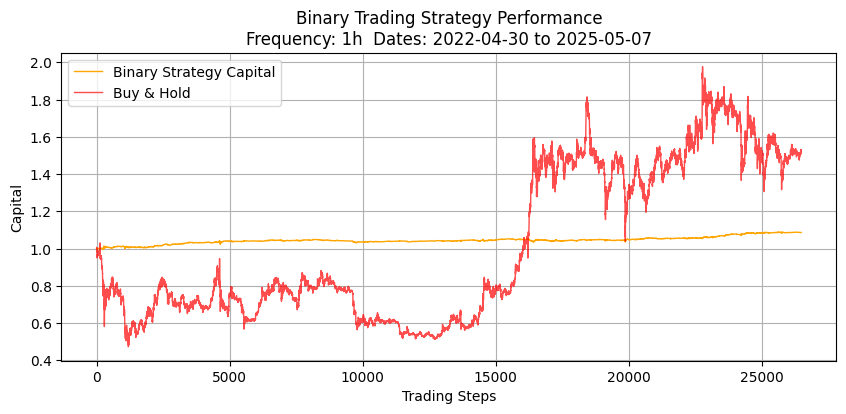

{'Total Return': np.float64(0.08673831638000817), 'Buy and Hold Return': np.float64(0.517189666036547), 'Hit Rate': np.float64(0.5063797659494149), 'Sharpe Ratio': np.float64(1.1443865665233095), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 52.26%
Hit Rate (Short/Price Fall): 49.29%
Number of Long Trades: 12001
Number of Short Trades: 14489
Binary-only trading simulation (aggressive)
Date range: 2022-04-30 04:00:00 to 2025-05-07 23:00:00
Binary plot saved as: images/binary_trading_simulation_13082025.png


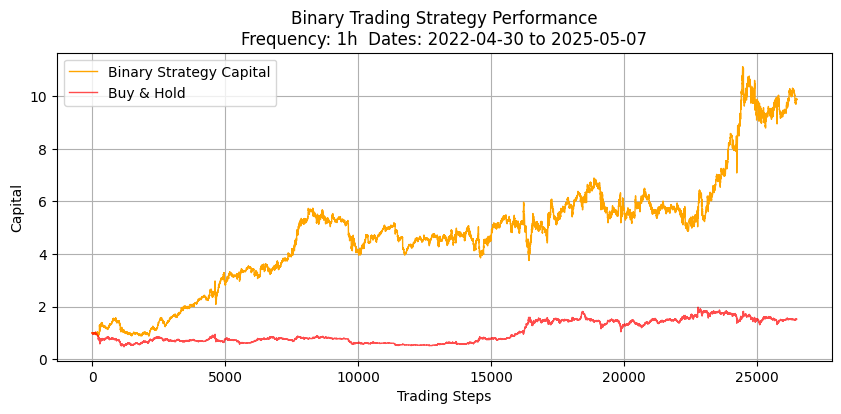

{'Total Return': np.float64(8.884899610678636), 'Buy and Hold Return': np.float64(0.517189666036547), 'Hit Rate': np.float64(0.5063797659494149), 'Sharpe Ratio': np.float64(0.980417861249029), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 52.26%
Hit Rate (Short/Price Fall): 49.29%
Number of Long Trades: 12001
Number of Short Trades: 14489
Ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


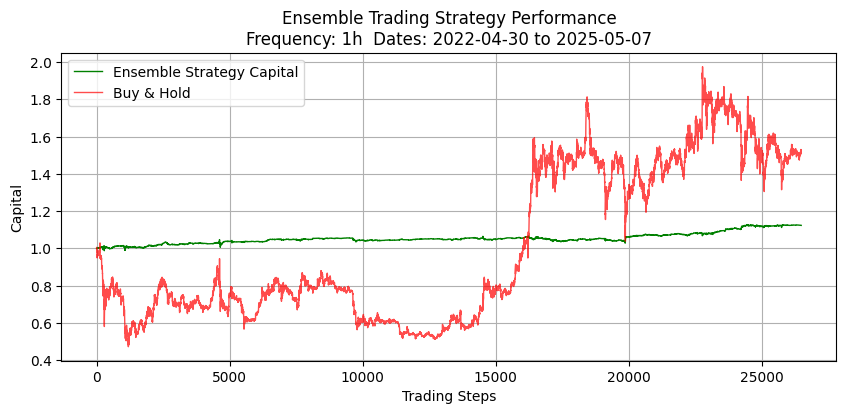

Ensemble Strategy Metrics: {'Total Return': np.float64(0.12383285596224991), 'Buy and Hold Return': np.float64(0.5156615888203452), 'Hit Rate': np.float64(0.5150424643731107), 'Sharpe Ratio': np.float64(0.948761912495135), 'Number of Trades': 13894}
Hit Rate (Long/Price Rise): 54.18%
Hit Rate (Short/Price Fall): 48.13%
Number of Long Trades: 7748
Number of Short Trades: 6146
Aggressive ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


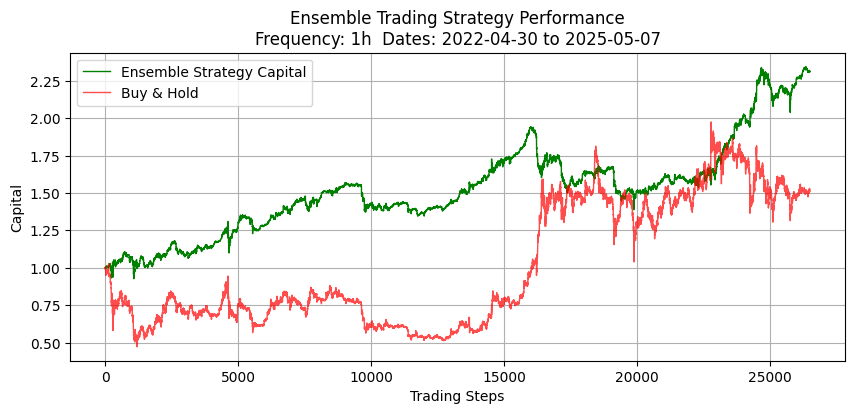

Ensemble Strategy Metrics: {'Total Return': np.float64(1.3124604026461073), 'Buy and Hold Return': np.float64(0.5156615888203452), 'Hit Rate': np.float64(0.5274219087375845), 'Sharpe Ratio': np.float64(1.2343137212762818), 'Number of Trades': 13894}
Hit Rate (Long/Price Rise): 53.57%
Hit Rate (Short/Price Fall): 50.44%
Number of Long Trades: 10238
Number of Short Trades: 3656
Testing BTC with trading window 1
Selected indicators: ['volatility_breakout' 'buy_volume_sentiment' 'sma_50' 'sma_200' 'ema_20'
 'ema_50' 'ema_200' 'rsi_14' 'bollinger_bands_20_2' 'obv' 'adx_14'
 'stochastic_oscillator_14' 'ichimoku_cloud_9_26_52' 'vwap' 'atr']
Training on: 2019-04-20 01:00:00 to 2022-04-30 02:00:00
Testing on: 2022-04-30 03:00:00 to 2025-05-08 00:00:00

=== Testing BALANCED LOGISTIC REGRESSION ===
Mean target_return: 0.00010939550027540065
Fraction positive: 0.5104375070778755
Fraction negative: 0.4893737495753275
Using features: ['volatility_breakout', 'buy_volume_sentiment', 'sma_50', 'sma_200

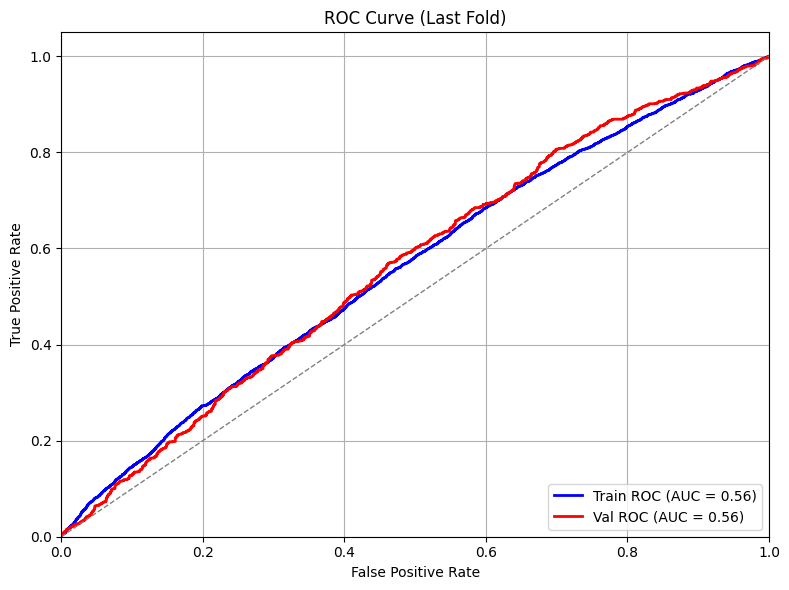

Logistic Regression (Balanced) Walk-Forward Validation Results (9 folds):
Avg Accuracy: 53.33%
Confusion Matrix (Total):
[[6568 5087]
 [5952 6045]]
Classification Report (Last Fold):
              precision    recall  f1-score   support

   Down/Flat       0.52      0.64      0.57      1291
          Up       0.56      0.44      0.49      1337

    accuracy                           0.54      2628
   macro avg       0.54      0.54      0.53      2628
weighted avg       0.54      0.54      0.53      2628

Testing balanced logistic regression on test set...
Test Model Results:
  R² Score: N/A (binary classification model)
  Test samples: 26491
  Features used: 31
  Overall Accuracy: 0.5331 (53.31%)
  Weighted Accuracy: 0.5331 (53.31%)
  Rise Accuracy: 0.3246 (32.46%) - 13428 samples
  Fall Accuracy: 0.7474 (74.74%) - 13063 samples
  Precision: 0.5691
  Recall: 0.3246
  F1 Score: 0.4134
  Confusion Matrix (Fall/Rise):
    [[9763 3300]  # Predicted Fall
     [9069 4359]]  # Predicted Rise


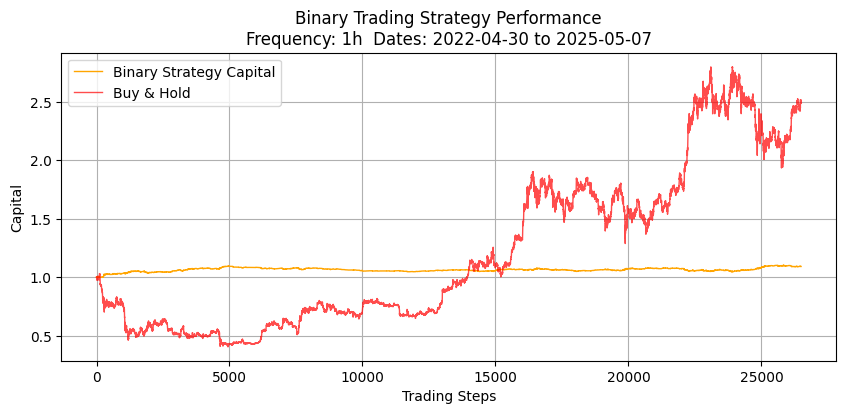

{'Total Return': np.float64(0.09210566758260819), 'Buy and Hold Return': np.float64(1.516089131482194), 'Hit Rate': np.float64(0.5142317855794639), 'Sharpe Ratio': np.float64(0.8267762486370649), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 53.68%
Hit Rate (Short/Price Fall): 50.51%
Number of Long Trades: 7659
Number of Short Trades: 18831
Binary-only trading simulation (aggressive)
Date range: 2022-04-30 04:00:00 to 2025-05-07 23:00:00
Binary plot saved as: images/binary_trading_simulation_13082025.png


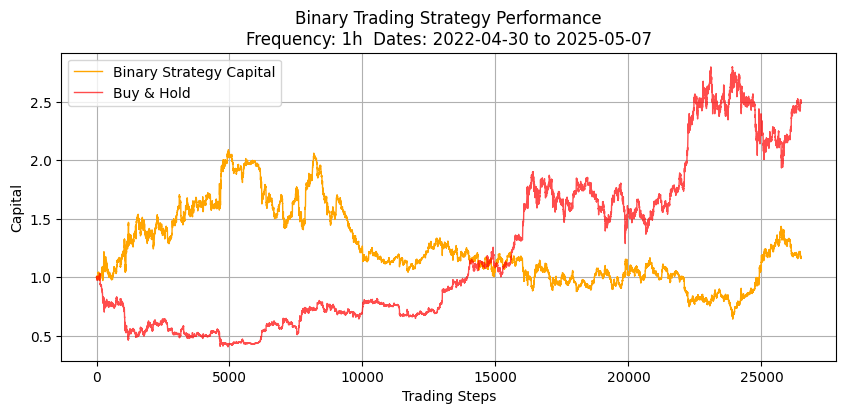

{'Total Return': np.float64(0.16240897450124403), 'Buy and Hold Return': np.float64(1.516089131482194), 'Hit Rate': np.float64(0.5142317855794639), 'Sharpe Ratio': np.float64(0.08096580619069224), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 53.68%
Hit Rate (Short/Price Fall): 50.51%
Number of Long Trades: 7659
Number of Short Trades: 18831
Ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


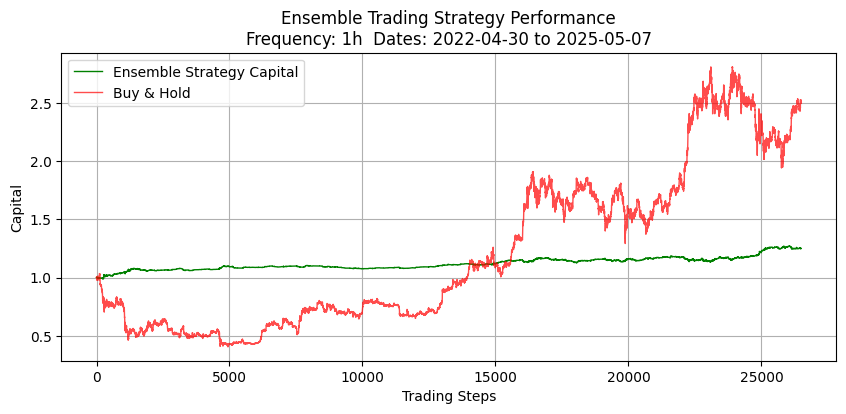

Ensemble Strategy Metrics: {'Total Return': np.float64(0.2491387184726246), 'Buy and Hold Return': np.float64(1.52281247637203), 'Hit Rate': np.float64(0.5178280286382647), 'Sharpe Ratio': np.float64(1.3374006108589016), 'Number of Trades': 14107}
Hit Rate (Long/Price Rise): 55.15%
Hit Rate (Short/Price Fall): 50.30%
Number of Long Trades: 4312
Number of Short Trades: 9795
Aggressive ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


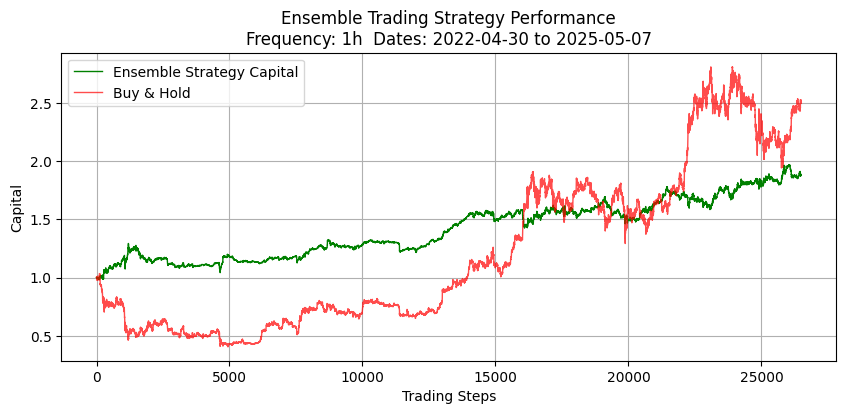

Ensemble Strategy Metrics: {'Total Return': np.float64(0.8777834297048914), 'Buy and Hold Return': np.float64(1.52281247637203), 'Hit Rate': np.float64(0.5368965761678599), 'Sharpe Ratio': np.float64(1.0466776729908203), 'Number of Trades': 14107}
Hit Rate (Long/Price Rise): 56.74%
Hit Rate (Short/Price Fall): 51.86%
Number of Long Trades: 5287
Number of Short Trades: 8820
Testing ETH with trading window 1
Selected indicators: ['volatility_breakout' 'buy_volume_sentiment' 'sma_50' 'sma_200' 'ema_20'
 'ema_50' 'ema_200' 'rsi_14' 'bollinger_bands_20_2' 'obv' 'adx_14'
 'stochastic_oscillator_14' 'ichimoku_cloud_9_26_52' 'vwap' 'atr']
Training on: 2019-04-20 01:00:00 to 2022-04-30 02:00:00
Testing on: 2022-04-30 03:00:00 to 2025-05-08 00:00:00

=== Testing BALANCED LOGISTIC REGRESSION ===
Mean target_return: 0.00015614739063441247
Fraction positive: 0.5089653089728587
Fraction negative: 0.4901287229625156
Using features: ['volatility_breakout', 'buy_volume_sentiment', 'sma_50', 'sma_200', 

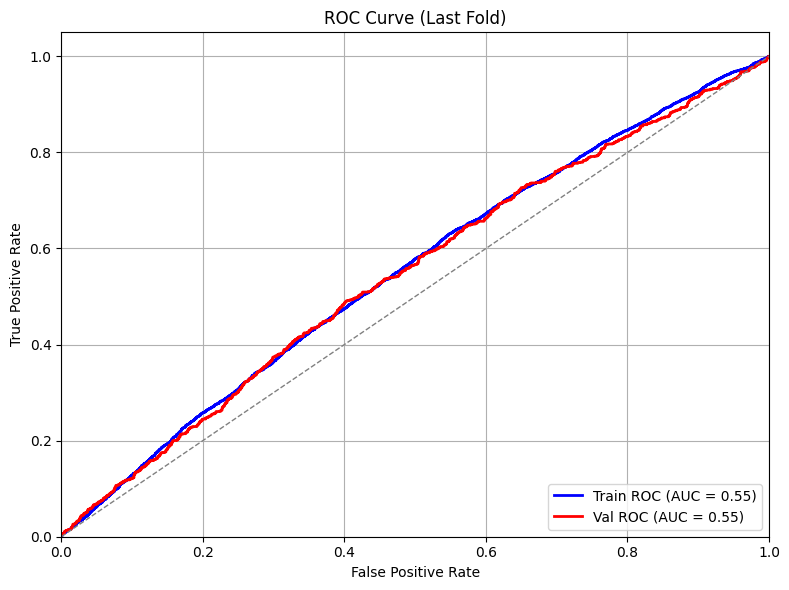

Logistic Regression (Balanced) Walk-Forward Validation Results (9 folds):
Avg Accuracy: 52.39%
Confusion Matrix (Total):
[[5554 5883]
 [5377 6838]]
Classification Report (Last Fold):
              precision    recall  f1-score   support

   Down/Flat       0.51      0.71      0.60      1285
          Up       0.56      0.35      0.43      1343

    accuracy                           0.53      2628
   macro avg       0.54      0.53      0.52      2628
weighted avg       0.54      0.53      0.51      2628

Testing balanced logistic regression on test set...
Test Model Results:
  R² Score: N/A (binary classification model)
  Test samples: 26491
  Features used: 31
  Overall Accuracy: 0.5138 (51.38%)
  Weighted Accuracy: 0.5138 (51.38%)
  Rise Accuracy: 0.1523 (15.23%) - 13305 samples
  Fall Accuracy: 0.8785 (87.85%) - 13186 samples
  Precision: 0.5586
  Recall: 0.1523
  F1 Score: 0.2394
  Confusion Matrix (Fall/Rise):
    [[11584 1602]  # Predicted Fall
     [11278 2027]]  # Predicted Ris

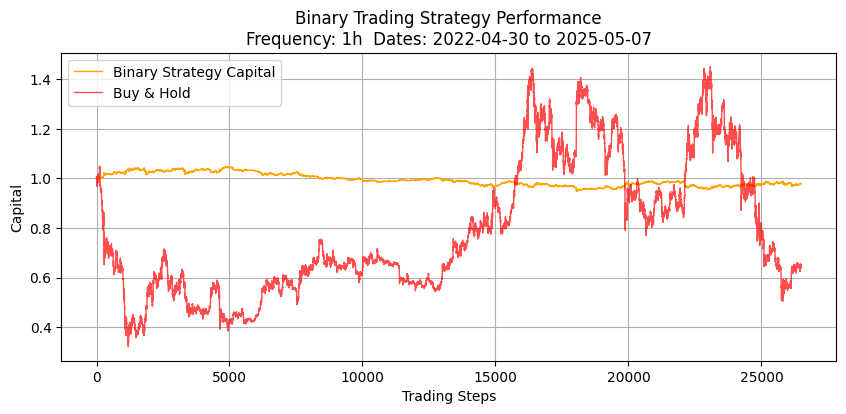

{'Total Return': np.float64(-0.0228975755258638), 'Buy and Hold Return': np.float64(-0.3552362889934056), 'Hit Rate': np.float64(0.5074367685919214), 'Sharpe Ratio': np.float64(-0.16624695118189475), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 53.73%
Hit Rate (Short/Price Fall): 50.27%
Number of Long Trades: 3629
Number of Short Trades: 22861
Binary-only trading simulation (aggressive)
Date range: 2022-04-30 04:00:00 to 2025-05-07 23:00:00
Binary plot saved as: images/binary_trading_simulation_13082025.png


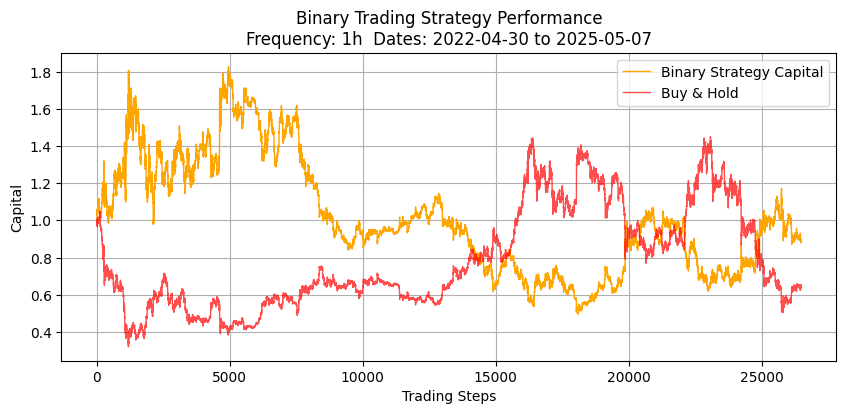

{'Total Return': np.float64(-0.11759952422143705), 'Buy and Hold Return': np.float64(-0.3552362889934056), 'Hit Rate': np.float64(0.5074367685919214), 'Sharpe Ratio': np.float64(-0.05187974080126816), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 53.73%
Hit Rate (Short/Price Fall): 50.27%
Number of Long Trades: 3629
Number of Short Trades: 22861
Ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


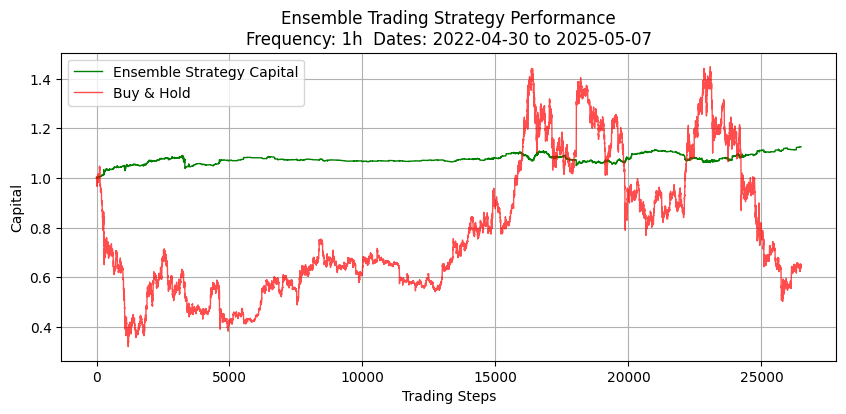

Ensemble Strategy Metrics: {'Total Return': np.float64(0.1259199546776435), 'Buy and Hold Return': np.float64(-0.35586025498095525), 'Hit Rate': np.float64(0.501964482162502), 'Sharpe Ratio': np.float64(0.762441848806816), 'Number of Trades': 6363}
Hit Rate (Long/Price Rise): 54.41%
Hit Rate (Short/Price Fall): 48.62%
Number of Long Trades: 1733
Number of Short Trades: 4630
Aggressive ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


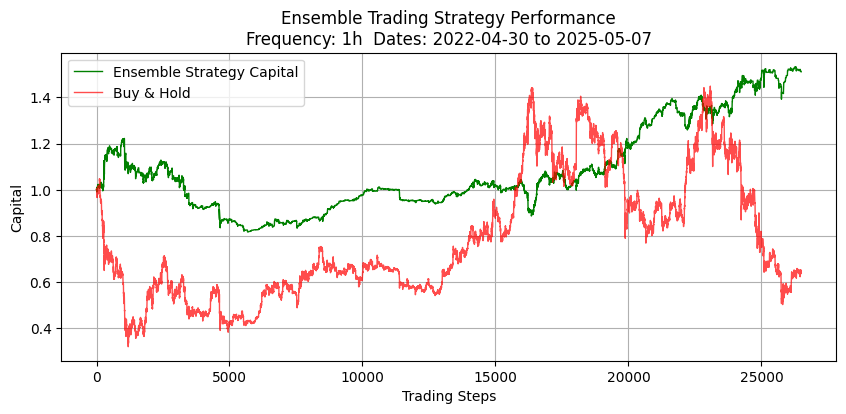

Ensemble Strategy Metrics: {'Total Return': np.float64(0.5104712793061794), 'Buy and Hold Return': np.float64(-0.35586025498095525), 'Hit Rate': np.float64(0.5363822096495364), 'Sharpe Ratio': np.float64(0.7595441270917862), 'Number of Trades': 6363}
Hit Rate (Long/Price Rise): 55.75%
Hit Rate (Short/Price Fall): 51.47%
Number of Long Trades: 3225
Number of Short Trades: 3138
Testing TRX with trading window 1
Selected indicators: ['buy_volume_sentiment' 'sma_50' 'sma_200' 'ema_20' 'ema_50' 'ema_200'
 'rsi_14' 'bollinger_bands_20_2' 'obv' 'adx_14' 'stochastic_oscillator_14'
 'ichimoku_cloud_9_26_52' 'vwap' 'atr']
Training on: 2019-04-20 01:00:00 to 2022-04-30 02:00:00
Testing on: 2022-04-30 03:00:00 to 2025-05-08 00:00:00

=== Testing BALANCED LOGISTIC REGRESSION ===
Mean target_return: 0.00010172305597998901
Fraction positive: 0.5055301800611528
Fraction negative: 0.48186176437280587
Using features: ['buy_volume_sentiment', 'sma_50', 'sma_200', 'ema_20', 'ema_50', 'ema_200', 'rsi_14', 

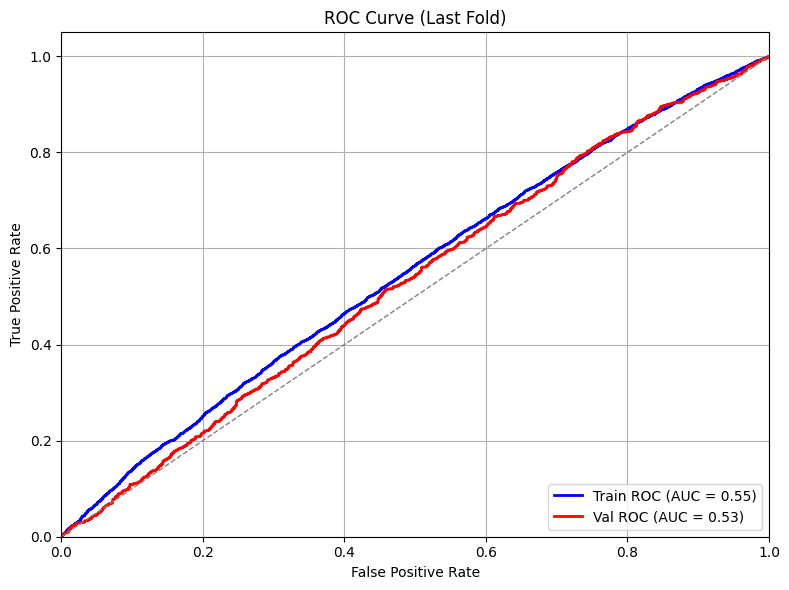

Logistic Regression (Balanced) Walk-Forward Validation Results (9 folds):
Avg Accuracy: 51.35%
Confusion Matrix (Total):
[[6477 4921]
 [6585 5669]]
Classification Report (Last Fold):
              precision    recall  f1-score   support

   Down/Flat       0.47      0.89      0.62      1240
          Up       0.53      0.11      0.18      1388

    accuracy                           0.48      2628
   macro avg       0.50      0.50      0.40      2628
weighted avg       0.51      0.48      0.39      2628

Testing balanced logistic regression on test set...
Test Model Results:
  R² Score: N/A (binary classification model)
  Test samples: 26491
  Features used: 30
  Overall Accuracy: 0.5122 (51.22%)
  Weighted Accuracy: 0.5122 (51.22%)
  Rise Accuracy: 0.7236 (72.36%) - 13625 samples
  Fall Accuracy: 0.2883 (28.83%) - 12866 samples
  Precision: 0.5185
  Recall: 0.7236
  F1 Score: 0.6041
  Confusion Matrix (Fall/Rise):
    [[3709 9157]  # Predicted Fall
     [3766 9859]]  # Predicted Rise


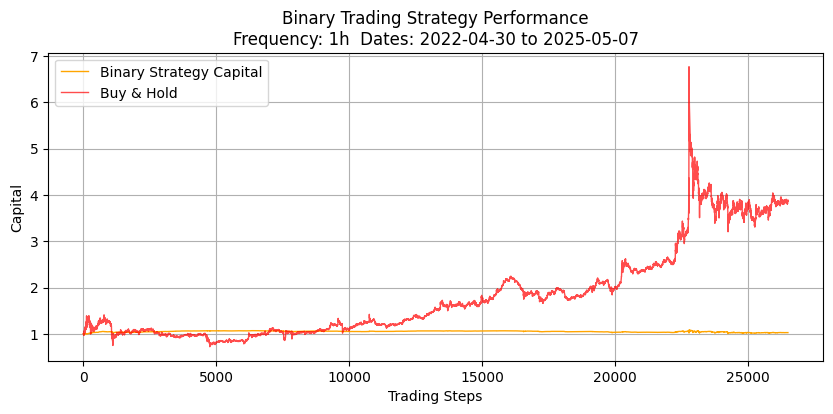

{'Total Return': np.float64(0.026903733005437136), 'Buy and Hold Return': np.float64(2.8862004370902277), 'Hit Rate': np.float64(0.5032465081162703), 'Sharpe Ratio': np.float64(0.15724442391910567), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 51.55%
Hit Rate (Short/Price Fall): 47.21%
Number of Long Trades: 19015
Number of Short Trades: 7475
Binary-only trading simulation (aggressive)
Date range: 2022-04-30 04:00:00 to 2025-05-07 23:00:00
Binary plot saved as: images/binary_trading_simulation_13082025.png


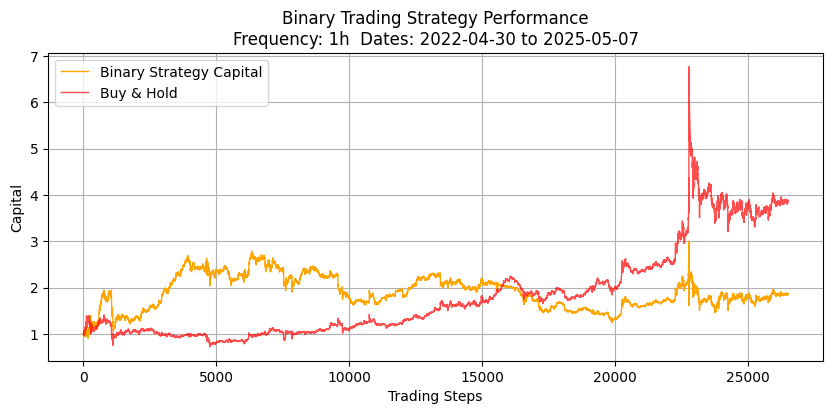

{'Total Return': np.float64(0.8693160898538026), 'Buy and Hold Return': np.float64(2.8862004370902277), 'Hit Rate': np.float64(0.5032465081162703), 'Sharpe Ratio': np.float64(0.2650853399730834), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 51.55%
Hit Rate (Short/Price Fall): 47.21%
Number of Long Trades: 19015
Number of Short Trades: 7475
Ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


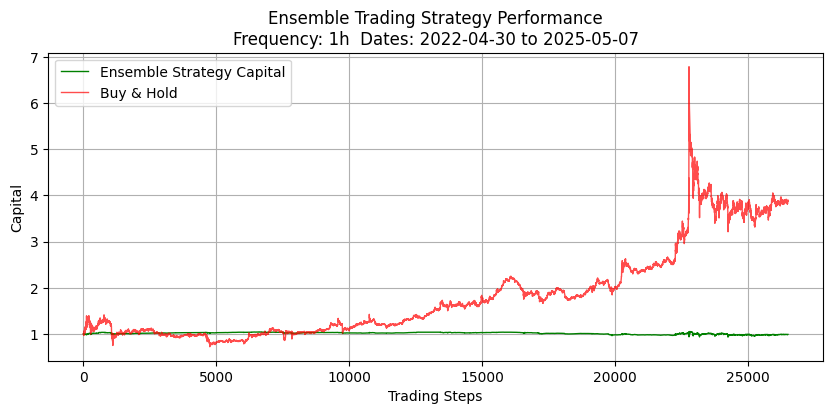

Ensemble Strategy Metrics: {'Total Return': np.float64(-0.01041109188684819), 'Buy and Hold Return': np.float64(2.8950168192130175), 'Hit Rate': np.float64(0.504899292324442), 'Sharpe Ratio': np.float64(-0.034255188376507824), 'Number of Trades': 18370}
Hit Rate (Long/Price Rise): 51.54%
Hit Rate (Short/Price Fall): 44.02%
Number of Long Trades: 15805
Number of Short Trades: 2565
Aggressive ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


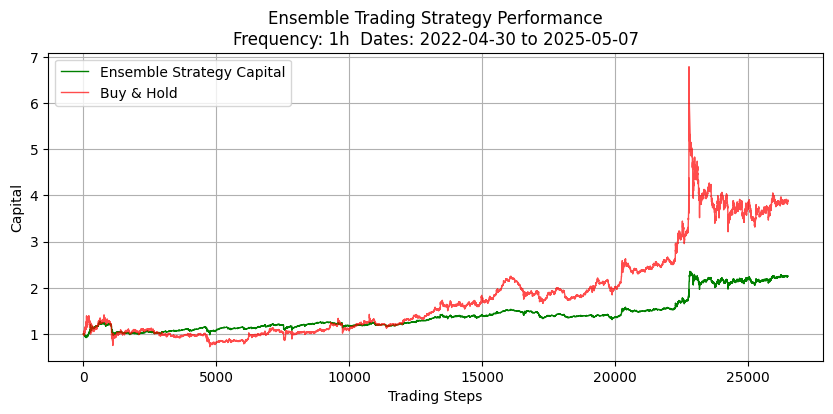

Ensemble Strategy Metrics: {'Total Return': np.float64(1.2566892837370385), 'Buy and Hold Return': np.float64(2.8950168192130175), 'Hit Rate': np.float64(0.520141535111595), 'Sharpe Ratio': np.float64(1.1032359806000704), 'Number of Trades': 18370}
Hit Rate (Long/Price Rise): 52.01%
Hit Rate (Short/Price Fall): 52.63%
Number of Long Trades: 18161
Number of Short Trades: 209
Testing XRP with trading window 1
Selected indicators: ['buy_volume_sentiment' 'sma_50' 'sma_200' 'ema_20' 'ema_50' 'ema_200'
 'rsi_14' 'bollinger_bands_20_2' 'obv' 'adx_14' 'stochastic_oscillator_14'
 'ichimoku_cloud_9_26_52' 'vwap' 'atr']
Training on: 2019-04-20 01:00:00 to 2022-04-30 02:00:00
Testing on: 2022-04-30 03:00:00 to 2025-05-08 00:00:00

=== Testing BALANCED LOGISTIC REGRESSION ===
Mean target_return: 0.0001052756968163596
Fraction positive: 0.5033785059076668
Fraction negative: 0.49450756860820655
Using features: ['buy_volume_sentiment', 'sma_50', 'sma_200', 'ema_20', 'ema_50', 'ema_200', 'rsi_14', 'bo

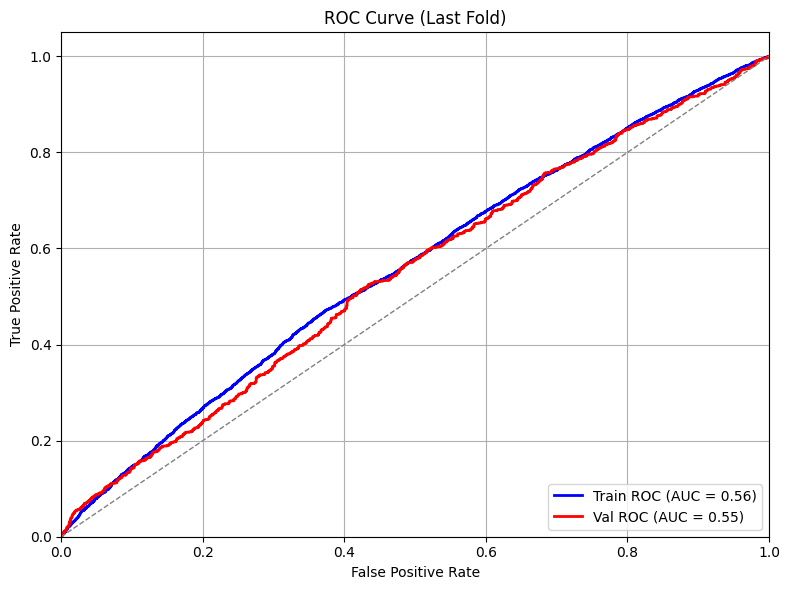

Logistic Regression (Balanced) Walk-Forward Validation Results (9 folds):
Avg Accuracy: 53.02%
Confusion Matrix (Total):
[[6691 4959]
 [6156 5855]]
Classification Report (Last Fold):
              precision    recall  f1-score   support

   Down/Flat       0.53      0.52      0.53      1300
          Up       0.54      0.55      0.55      1329

    accuracy                           0.54      2629
   macro avg       0.54      0.54      0.54      2629
weighted avg       0.54      0.54      0.54      2629

Testing balanced logistic regression on test set...
Test Model Results:
  R² Score: N/A (binary classification model)
  Test samples: 26491
  Features used: 30
  Overall Accuracy: 0.5395 (53.95%)
  Weighted Accuracy: 0.5395 (53.95%)
  Rise Accuracy: 0.6010 (60.10%) - 13395 samples
  Fall Accuracy: 0.4766 (47.66%) - 13096 samples
  Precision: 0.5401
  Recall: 0.6010
  F1 Score: 0.5689
  Confusion Matrix (Fall/Rise):
    [[6241 6855]  # Predicted Fall
     [5345 8050]]  # Predicted Rise


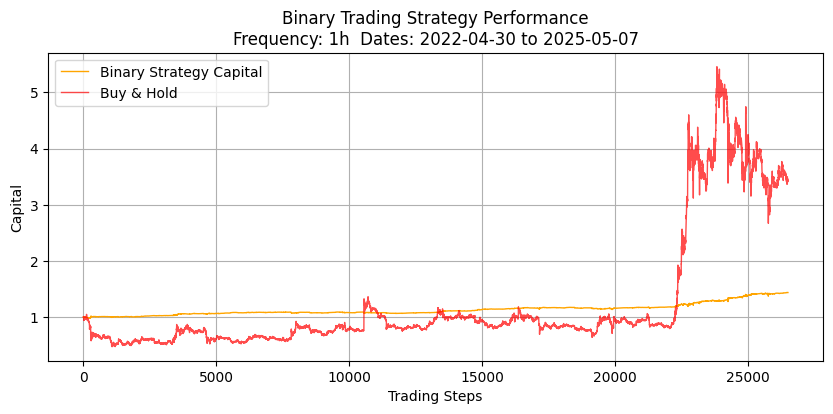

{'Total Return': np.float64(0.43839823319838844), 'Buy and Hold Return': np.float64(2.4329164985881406), 'Hit Rate': np.float64(0.5218573046432616), 'Sharpe Ratio': np.float64(1.6893843445552605), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 52.93%
Hit Rate (Short/Price Fall): 51.23%
Number of Long Trades: 14905
Number of Short Trades: 11585
Binary-only trading simulation (aggressive)
Date range: 2022-04-30 04:00:00 to 2025-05-07 23:00:00
Binary plot saved as: images/binary_trading_simulation_13082025.png


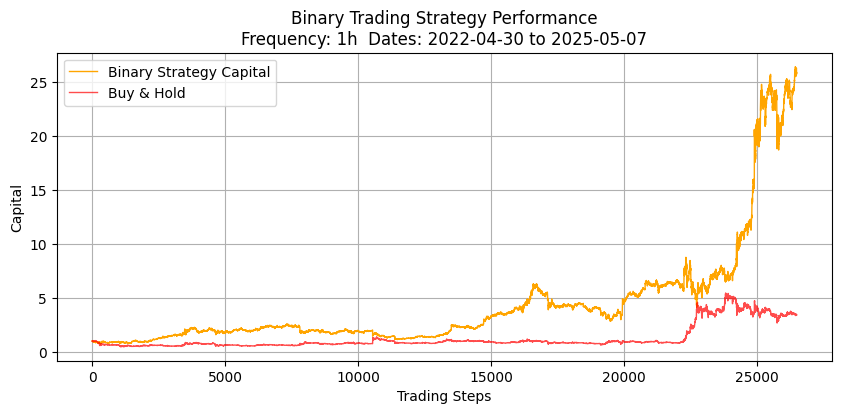

{'Total Return': np.float64(24.872576380741766), 'Buy and Hold Return': np.float64(2.4329164985881406), 'Hit Rate': np.float64(0.5218573046432616), 'Sharpe Ratio': np.float64(1.2390081505464627), 'Number of Trades': 26490}
Hit Rate (Long/Price Rise): 52.93%
Hit Rate (Short/Price Fall): 51.23%
Number of Long Trades: 14905
Number of Short Trades: 11585
Ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


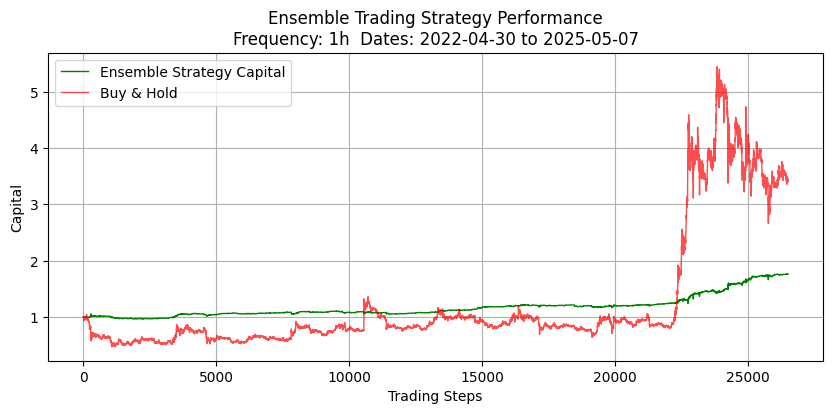

Ensemble Strategy Metrics: {'Total Return': np.float64(0.7650416792265269), 'Buy and Hold Return': np.float64(2.427386226339106), 'Hit Rate': np.float64(0.5307389774373835), 'Sharpe Ratio': np.float64(1.521206794021564), 'Number of Trades': 14493}
Hit Rate (Long/Price Rise): 53.58%
Hit Rate (Short/Price Fall): 52.40%
Number of Long Trades: 8266
Number of Short Trades: 6227
Aggressive ensemble trading simulation (linear + balanced binary)
Date range: 2022-04-30 05:00:00 to 2025-05-07 23:00:00
Ensemble plot saved as: images/ensemble_trading_simulation_13082025.png


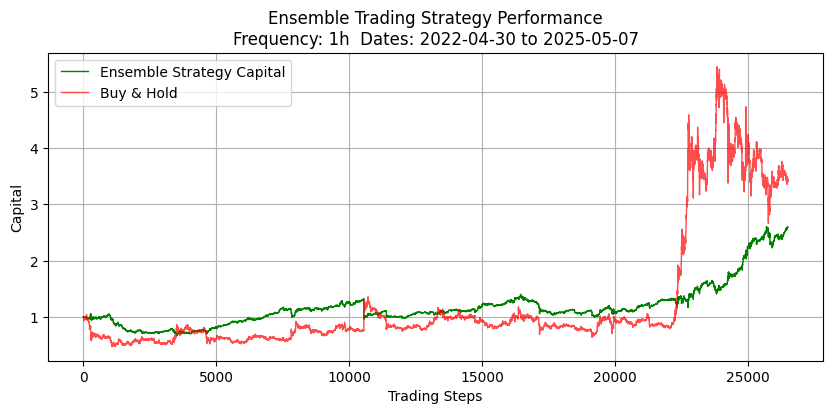

Ensemble Strategy Metrics: {'Total Return': np.float64(1.6044601673950765), 'Buy and Hold Return': np.float64(2.427386226339106), 'Hit Rate': np.float64(0.5376388601393777), 'Sharpe Ratio': np.float64(1.1732760397247415), 'Number of Trades': 14493}
Hit Rate (Long/Price Rise): 54.33%
Hit Rate (Short/Price Fall): 53.06%
Number of Long Trades: 8046
Number of Short Trades: 6447
Balanced logistic regression testing complete!


In [3]:
import os
import pandas as pd
import numpy as np
from regression import run_indicators, test_model
from trading import simulate_trading, simulate_trading_ensemble, simulate_trading_binary
import importlib

indicator_module = importlib.import_module('indicators')

original_columns = [
    'bam_vwa', 'bam_open', 'bam_close',
    'bam_high', 'bam_low', 'bam_volatility_1m_return', 'base_volume',
    'pct_buy_volume', 'annual_interest_rate', 'spread_1m_vwa_vwa',
    'spread_twa'
]
symbols = ['BNB', 'BTC', 'ETH', 'TRX', 'XRP']

for symbol in symbols:
    for trading_window in range(1, 2):
        print(f"Testing {symbol} with trading window {trading_window}")
        try:
            df = pd.read_csv(f'indicator_results_{symbol}.csv')
            df1 = df[df['window'] == trading_window]

            selected_indicators = df1[df1['weighted_win'] > 0.50]['indicator'].unique() # We can add more complex selection logic here.
            if len(selected_indicators) == 0:
                print(f"No indicators with win rate > 50% for {symbol} - {trading_window}h window")
                continue
            print(f"Selected indicators: {selected_indicators}")

            df_symbol = pd.read_csv(f'{symbol}_spot_full.csv')
            half = len(df_symbol) // 2
            df_train = df_symbol.iloc[:half]
            
            # Get start time for testing (second half of data)
            start_time = df_symbol.iloc[half]['close_time']
            
            print(f"Training on: {df_train.iloc[0]['close_time']} to {df_train.iloc[-1]['close_time']}")
            print(f"Testing on: {start_time} to {df_symbol.iloc[-1]['close_time']}")

            print(f"\n=== Testing BALANCED LOGISTIC REGRESSION ===")
            try:
                # Test with balanced class weights
                # we test some basic strategy here. We can use Kelly's criterion or other methods for a better approach and combine capital allocation 
                # between different coins.
                linear, binary, scaler = run_indicators(df_train, selected_indicators.tolist() + original_columns, 
                                               time_window=trading_window, quantile=False, obj=None)
                
                if linear is not None and binary is not None and scaler is not None:
                    print(f"Testing balanced logistic regression on test set...")
                    r2_binary = test_model(df_symbol, binary, selected_indicators.tolist(), original_columns, 
                                         target_col='bam_close', time_window=trading_window, start_time=start_time, scaler=scaler)
                    
                    print(f"Binary-only trading simulation (balanced model)")
                    simulate_trading_binary(df_symbol, binary, selected_indicators.tolist() + original_columns,
                                         start_time=start_time,
                                         trading_window=trading_window, plot=True, strategy='prob', scaler=scaler)
                    
                    print(f"Binary-only trading simulation (aggressive)")
                    simulate_trading_binary(df_symbol, binary, selected_indicators.tolist() + original_columns,
                                         start_time=start_time,
                                         trading_window=trading_window, plot=True, strategy='aggressive', scaler=scaler)
                    
                    print(f"Ensemble trading simulation (linear + balanced binary)")
                    simulate_trading_ensemble(df_symbol, linear, binary, selected_indicators.tolist() + original_columns,
                                           start_time=start_time,
                                           trading_window=trading_window, plot=True, strategy='proba_ensemble', scaler=scaler)
                    
                    print(f"Aggressive ensemble trading simulation (linear + balanced binary)")
                    simulate_trading_ensemble(df_symbol, linear, binary, selected_indicators.tolist() + original_columns,
                                           start_time=start_time,
                                           trading_window=trading_window, plot=True, strategy='aggressive_ensemble', scaler=scaler)
                else:
                    print(f"Failed to create balanced logistic regression model")
                    
            except Exception as e:
                print(f"Error with balanced logistic regression: {str(e)}")
                continue
                    
        except Exception as e:
            print(f"Error processing {symbol} - {trading_window}h: {str(e)}")
            continue

print("Balanced logistic regression testing complete!")
